# Runoff Forecasting (3-Day Ahead)

Step-by-step workflow from data preparation to Random Forest evaluation.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Import new modules for visualization and automated training
from visualization import generate_all_plots
from model_training_backend import auto_train_best_model, train_lstm_with_early_stopping

## Step 1 - Load and Prepare Data

In [2]:
# Load dataset
try:
    df = pd.read_excel("datasets/Kasol.xlsx", sheet_name="Sheet1")
except FileNotFoundError:
    df = pd.read_csv("datasets/Kasol.csv")

# Convert DATE to datetime
df["DATE"] = pd.to_datetime(df["DATE"])

# Sort by date (very important for time series)
df = df.sort_values("DATE").reset_index(drop=True)

# Quick check
print(df.head())
print(df.shape)

   Discharge (CUMEC)       DATE  PCP    TMAX  TMIN        rh      solar  \
0           12709440 1979-01-01  0.0  19.655   8.9  0.732263   0.073350   
1           12709440 1979-01-02  0.0  23.992   7.8  0.714852  13.519409   
2           12709440 1979-01-03  0.0  21.204   8.9  0.678937  13.472386   
3           12709440 1979-01-04  0.0  19.318  10.0  0.697823  13.352567   
4           12674880 1979-01-05  0.0  16.913   8.9  0.705512  13.652832   

      wind    P1   P2   P3  
0  6.242386  0.0  0.0  0.0  
1  4.099394  0.0  0.0  0.0  
2  4.972107  0.0  0.0  0.0  
3  5.057122  0.0  0.0  0.0  
4  4.769179  0.0  0.0  0.0  
(11323, 11)


## Step 2-7 - Build Target and Features

In [3]:
# Step 2: Create 3-day ahead target
df["Target_t_plus_3"] = df["Discharge (CUMEC)"].shift(-3)

# Drop last 3 rows (no future value available)
df = df.dropna().reset_index(drop=True)

# Step 3: Add discharge lags
df["Discharge_t-1"] = df["Discharge (CUMEC)"].shift(1)
df["Discharge_t-2"] = df["Discharge (CUMEC)"].shift(2)
df["Discharge_t-3"] = df["Discharge (CUMEC)"].shift(3)

# Step 4: Rainfall memory features
df["PCP_rolling_3"] = df["PCP"].rolling(window=3).sum()
df["PCP_rolling_7"] = df["PCP"].rolling(window=7).sum()
df["P1_rolling_3"] = df["P1"].rolling(window=3).sum()
df["P1_rolling_7"] = df["P1"].rolling(window=7).sum()
df["P2_rolling_3"] = df["P2"].rolling(window=3).sum()
df["P2_rolling_7"] = df["P2"].rolling(window=7).sum()
df["P3_rolling_3"] = df["P3"].rolling(window=3).sum()
df["P3_rolling_7"] = df["P3"].rolling(window=7).sum()

# Step 5: Temperature features
df["Temp_mean"] = (df["TMAX"] + df["TMIN"]) / 2
df["Temp_range"] = df["TMAX"] - df["TMIN"]

# Step 6: Seasonal encoding
day_of_year = df["DATE"].dt.dayofyear
df["sin_doy"] = np.sin(2 * np.pi * day_of_year / 365)
df["cos_doy"] = np.cos(2 * np.pi * day_of_year / 365)

# Step 7: Drop NaNs created by lags/rolling windows
df = df.dropna().reset_index(drop=True)

print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (11308, 27)


,Discharge (CUMEC),DATE,PCP,TMAX,TMIN,rh,solar,wind,P1,P2,...,P1_rolling_3,P1_rolling_7,P2_rolling_3,P2_rolling_7,P3_rolling_3,P3_rolling_7,Temp_mean,Temp_range,sin_doy,cos_doy
0,12355200,1979-01-07,0.0,23.672,6.7,0.696621,13.801778,4.388498,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,15.1860,16.972,0.120208,0.992749
1,12424320,1979-01-08,0.0,13.954,7.8,0.665452,13.674088,4.890416,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,10.8770,6.154,0.137279,0.990532
2,12355200,1979-01-09,0.0,19.991,8.9,0.661299,13.618517,4.992635,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,14.4455,11.091,0.154309,0.988023
3,12355200,1979-01-10,0.0,19.817,10.0,0.612094,13.651710,5.226373,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,14.9085,9.817,0.171293,0.985220
4,12320640,1979-01-11,0.0,20.220,10.0,0.635455,13.907760,5.404962,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,15.1100,10.220,0.188227,0.982126


## Step 8 - Select Features and Prepare X, y

In [4]:
# Select input features
feature_cols = [
    "PCP",
    "P1",
    "P2",
    "P3",
    "PCP_rolling_3",
    "PCP_rolling_7",
    "P1_rolling_3",
    "P1_rolling_7",
    "P2_rolling_3",
    "P2_rolling_7",
    "P3_rolling_3",
    "P3_rolling_7",
    "TMAX",
    "TMIN",
    "Temp_mean",
    "Temp_range",
    "rh",
    "solar",
    "wind ",
    "Discharge_t-1",
    "Discharge_t-2",
    "Discharge_t-3",
    "sin_doy",
    "cos_doy"
]

X = df[feature_cols]
y = df["Target_t_plus_3"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (11308, 24)
Target shape: (11308,)


## Step 9-13 - Split, Train, Predict, Evaluate

In [5]:
# Step 9: Time-based train/test split
df["Year"] = df["DATE"].dt.year

# Train: 1979-2000
train = df[df["Year"] <= 2000]

# Test: 2006-2009
test = df[df["Year"] >= 2006]

X_train = train[feature_cols]
y_train = train["Target_t_plus_3"]
X_test = test[feature_cols]
y_test = test["Target_t_plus_3"]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# Step 10: Train Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Step 11: Make predictions
y_pred = rf_model.predict(X_test)

# Step 12: Evaluate performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

# Step 13: Nash-Sutcliffe Efficiency
def nse(obs, pred):
    return 1 - (np.sum((obs - pred)**2) / np.sum((obs - np.mean(obs))**2))

nse_value = nse(y_test.values, y_pred)
print("NSE:", nse_value)

Train size: (8026, 24)
Test size: (1456, 24)
RMSE: 11463997.34516432
MAE: 5939262.634097393
R2: 0.8485300189457401
NSE: 0.8485300189457401


In [6]:
# Feature importance
importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(10)

Discharge_t-1    0.913046
cos_doy          0.019743
TMIN             0.006881
wind             0.006856
sin_doy          0.006086
solar            0.005625
Discharge_t-3    0.004380
rh               0.004289
Discharge_t-2    0.003330
P3_rolling_7     0.003261
dtype: float64

## Step 14 - Extreme Event Evaluation (Top 10%)

In [7]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Define extreme threshold (top 10%)
threshold = np.percentile(y_test, 90)
extreme_mask = y_test >= threshold

y_test_extreme = y_test[extreme_mask]
y_pred_extreme = y_pred[extreme_mask]

rmse_extreme = np.sqrt(mean_squared_error(y_test_extreme, y_pred_extreme))

def nse(obs, pred):
    return 1 - (np.sum((obs - pred)**2) /
                np.sum((obs - np.mean(obs))**2))

nse_extreme = nse(y_test_extreme.values, y_pred_extreme)

print("Extreme RMSE:", rmse_extreme)
print("Extreme NSE:", nse_extreme)

Extreme RMSE: 24569760.39938007
Extreme NSE: -0.6455246554674778


## Step 15 - Visual Check (First 200 Test Days)

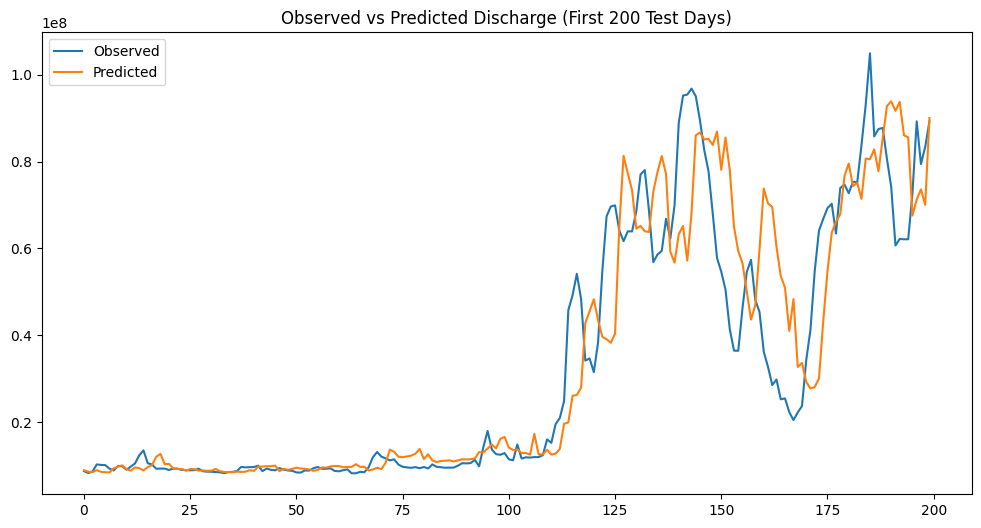

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:200], label="Observed")
plt.plot(y_pred[:200], label="Predicted")
plt.legend()
plt.title("Observed vs Predicted Discharge (First 200 Test Days)")
plt.show()

## Step 16 - LSTM Sequence Setup (Window 14, Horizon 3)

In [9]:
# Decide sequence structure
window_size = 14
horizon = 3

# Select features for LSTM (no lag columns)
lstm_features = [
    "Discharge (CUMEC)",
    "PCP",
    "P1",
    "P2",
    "P3",
    "TMAX",
    "TMIN",
    "rh",
    "solar",
    "wind ",
    "sin_doy",
    "cos_doy"
]

# Scale data for LSTM
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[lstm_features])
scaled_df = pd.DataFrame(scaled_data, columns=lstm_features)

## Step 17 - Create LSTM Sequences

In [10]:
X_seq = []
y_seq = []

for i in range(window_size, len(scaled_df) - horizon):
    X_seq.append(scaled_df.iloc[i-window_size:i].values)
    y_seq.append(df["Discharge (CUMEC)"].iloc[i + horizon])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("X shape:", X_seq.shape)
print("y shape:", y_seq.shape)

X shape: (11291, 14, 12)
y shape: (11291,)


## Step 18 - Time-Based Sequence Split

In [11]:
# Align dates with sequences
sequence_dates = df["DATE"].iloc[window_size:len(df)-horizon].reset_index(drop=True)

# Create masks
train_mask = sequence_dates.dt.year <= 2000
test_mask = sequence_dates.dt.year >= 2006

X_train = X_seq[train_mask]
y_train = y_seq[train_mask]
X_test = X_seq[test_mask]
y_test = y_seq[test_mask]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8012, 14, 12)
Test shape: (1453, 14, 12)


## Step 6 - Build LSTM Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

c:\Users\shivr\Documents\GitHub\ai-based-runoff-prediction\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 14, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,673 (127.63 KB)

 Trainable params: 32,673 (127.63 KB)

 Non-trainable params: 0 (0.00 B)

## Step 7 - Train LSTM with Early Stopping

In [14]:
from sklearn.preprocessing import MinMaxScaler

# Scale target using training set only
y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1))

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train_scaled,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("Epochs trained:", len(history.history['loss']))
print("EarlyStopping triggered:", len(history.history['loss']) < 50)
print("Best val loss:", min(history.history['val_loss']))
print("Final train loss:", history.history['loss'][-1])
print("Final val loss:", history.history['val_loss'][-1])

Epoch 1/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0047 - mae: 0.0414 - val_loss: 0.0034 - val_mae: 0.0325
Epoch 2/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0036 - mae: 0.0343 - val_loss: 0.0030 - val_mae: 0.0293
Epoch 3/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0033 - mae: 0.0326 - val_loss: 0.0030 - val_mae: 0.0303
Epoch 4/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0032 - mae: 0.0320 - val_loss: 0.0032 - val_mae: 0.0313
Epoch 5/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0031 - mae: 0.0317 - val_loss: 0.0041 - val_mae: 0.0370
Epoch 6/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0031 - mae: 0.0316 - val_loss: 0.0032 - val_mae: 0.0307
Epoch 7/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0029 - mae: 0.0307 - val_loss: 0.0028 - val_mae: 0.0279
Epoch 8/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.0028 - mae: 0.0304 - val_loss: 0.0031 - val_mae: 0.0308
Epoch 9/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms

## Step 8-10 - Predict and Evaluate (Overall + Extreme)

In [15]:
# Step 8: Make predictions
y_pred_scaled = model.predict(X_test)
y_pred_lstm = y_scaler.inverse_transform(y_pred_scaled).flatten()

# Step 9: Evaluate performance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
r2_lstm = r2_score(y_test, y_pred_lstm)

def nse(obs, pred):
    return 1 - (np.sum((obs - pred)**2) /
                np.sum((obs - np.mean(obs))**2))

nse_lstm = nse(y_test, y_pred_lstm)

print("LSTM RMSE:", rmse_lstm)
print("LSTM R2:", r2_lstm)
print("LSTM NSE:", nse_lstm)

# Step 10: Extreme event evaluation
threshold = np.percentile(y_test, 90)
mask = y_test >= threshold

y_test_ext = y_test[mask]
y_pred_ext = y_pred_lstm[mask]

rmse_ext = np.sqrt(mean_squared_error(y_test_ext, y_pred_ext))
nse_ext = nse(y_test_ext, y_pred_ext)

print("LSTM Extreme RMSE:", rmse_ext)
print("LSTM Extreme NSE:", nse_ext)

46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
LSTM RMSE: 13709113.133902717
LSTM R2: 0.7835828065872192
LSTM NSE: 0.7835827649283952
LSTM Extreme RMSE: 24133637.561438598
LSTM Extreme NSE: -0.5876257155594815


## Step 21 - Automated Best Model Selection with Hyperparameter Tuning

In [ ]:
# Run automated best model selection with hyperparameter tuning
best_model_result = auto_train_best_model(
    df=df,
    feature_cols=feature_cols,
    target_col='Discharge',
    train_size=0.8,
    test_years_start=2006,
    test_years_end=2009,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("\n" + "="*60)
print("AUTOMATED MODEL SELECTION COMPLETE")
print("="*60)
print(f"Best Model: {best_model_result['best_model']}")
print(f"Best Model RMSE: {best_model_result['best_rmse']:.2f}")
print(f"Model Comparison:")
for model_cmp in best_model_result['all_models']:
    print(f"  - {model_cmp['model_name']}: RMSE={model_cmp['rmse']:.2f}")
print("="*60)